# 04: Entrenamiento y Optimización del Re-Ordenador Supervisado (LGBMRanker con LambdaRank)

**TFM: Motor de Recomendación Escalable para Retail de Moda**  
**Autor:** Manuel Valdivia  
**Máster:** Máster en Data Science, Big Data & Business Analytics: Universidad Complutense de Madrid  

---

### Contexto Metodológico y Formulación de Learning to Rank (LTR)

En arquitecturas desacopladas de recomendación (*Two-Stage Recommender Systems*), la fase de recuperación de candidatos prioriza la sensibilidad global (Recall@80), generando una lista heterogénea de hasta 80 prendas plausibles por cliente. La segunda etapa consiste en un modelo de re-ordenación supervisado (*Supervised Re-Ranking*) cuyo objetivo es optimizar la permutación listwise dentro de la ventana de corte contractual ($K=12$).

#### 1. Limitaciones del Paradigma Pointwise (Clasificación Binaria)
El enfoque convencional de modelar la recomendación como una clasificación binaria independiente mediante Entropía Cruzada Binaria (BCE):
$$\mathcal{L}_{\text{BCE}} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \right]$$
presenta tres fallos estructurales para sistemas de recomendación:
1. **Asunción de Independencia Condicional:** Trata cada par usuario-artículo como una observación aislada, ignorando que el usuario selecciona prendas comparando las alternativas disponibles en la misma lista.
2. **Calibración de Probabilidad vs. Ordenamiento Relativo:** Minimizar el error de calibración en la probabilidad posterior absoluta $\hat{p}(y=1|u, a)$ no garantiza que el orden relativo de las puntuaciones en el Top-12 maximice la métrica de negocio.
3. **Desensibilización ante la Posición:** Errar en predecir un candidato irrelevante en la posición 1 conlleva la misma penalización de pérdida que errar en la posición 75, a pesar de que el impacto en la experiencia del cliente es radicalmente distinto.

#### 2. Formulación Analítica de LambdaRank y LambdaMART
Para superar estas limitaciones, adoptamos **LambdaMART** con función objetivo `lambdarank`. LambdaRank elude la no-diferenciabilidad y discontinuidad de las métricas discretas basadas en ranking (como NDCG@12 y MAP@12) definiendo pseudo-gradientes virtuales (fuerzas $\lambda_{ij}$) para cada par de artículos $(i, j)$ evaluados para el mismo usuario:

$$\lambda_{ij} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} |\Delta \text{NDCG}_{ij}|$$

donde:
* $s_i, s_j$ son las puntuaciones continuas de salida predichas por el ensamble para los artículos $i$ y $j$.
* $\sigma$ es un factor de escala de sigmoide.
* $|\Delta \text{NDCG}_{ij}|$ representa el cambio absoluto en la métrica NDCG (o MAP) que resultaría de intercambiar las posiciones de los artículos $i$ y $j$ en el ranking actual.

De este modo, los pares donde un artículo relevante se encuentra por debajo de uno irrelevante reciben una fuerza correctiva proporcional al impacto directo sobre la métrica de negocio en la lista Top-12.

---

<!-- ARCHITECTURE_DIAGRAM_START -->
### Pipeline de Entrenamiento y Optimización con LGBMRanker (LambdaRank)
Agrupamiento de consultas por customer_idx, negative downsampling 1:5, optimización pairwise LambdaRank y validación temporal oficial de MAP@12.

![Pipeline de Entrenamiento y Optimización con LGBMRanker (LambdaRank)](../results/figures/diag_04_lgbm_ranker_training.png)
<!-- ARCHITECTURE_DIAGRAM_END -->


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(BASE_DIR))

from config.settings import (
    DATA_PROCESSED_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    LGBM_PARAMS,
    RANDOM_SEED,
)
from src.modeling.ranker import LGBMRankerModel
from src.evaluation.metrics import ap_at_k, map_at_k
from src.visualization.style import (
    COLOR_PRIMARY,
    COLOR_SECONDARY,
    COLOR_ACCENT,
    COLOR_HIGHLIGHT,
    COLOR_MUTED,
    COLOR_GRAY,
    set_editorial_style,
)

set_editorial_style()
print("✓ Entorno configurado correctamente para evaluación de entrenamiento y ranking.")


✓ Entorno configurado correctamente para evaluación de entrenamiento y ranking.


## 1. Particionado Temporal Estricto y Estructura de Consultas (`query_groups`)

### Protocolo de Validación Temporal sin Fuga de Información
Siguiendo las mejores prácticas de evaluación en e-commerce, se aplica una partición temporal estricta sobre las 5 semanas de la ventana de modelado:
* **Conjunto de Entrenamiento (Semanas 100 a 103):** 1.094.636 transacciones (2020-08-18 a 2020-09-15).
* **Conjunto de Validación Retenido (Semana 104):** 240.311 transacciones (2020-09-16 a 2020-09-22) correspondientes a 68.984 clientes activos únicos.

### Estructura de Consulta en Modelos Listwise / Pairwise
A diferencia de los clasificadores estándar que procesan filas independientes, un modelo de ranking requiere estructurar el espacio de datos en **sesiones de consulta** (*query groups*):
* Cada cliente único $u$ constituye un grupo independiente $q_u$.
* Las filas correspondientes a los candidatos de un mismo usuario deben disponerse de forma estrictamente contigua en memoria física (ordenadas por `customer_idx`).
* Se construye el vector de longitudes de grupo:
$$\mathbf{q} = \left[ |C_{u_1}|, |C_{u_2}|, \dots, |C_{u_M}| \right], \quad \sum_{m=1}^{M} |C_{u_m}| = N$$
donde $|C_{u_m}|$ es el número de candidatos evaluados para el cliente $m$ (acotado a un máximo de 80 por diseño).


In [2]:
print("HIPERPARÁMETROS DE PRODUCCIÓN (LGBM_PARAMS):")
print("-" * 75)
for k, v in LGBM_PARAMS.items():
    print(f"  * {k:<22}: {v}")


HIPERPARÁMETROS DE PRODUCCIÓN (LGBM_PARAMS):
---------------------------------------------------------------------------
  * objective             : lambdarank
  * metric                : map
  * eval_at               : [12]
  * boosting_type         : gbdt
  * n_estimators          : 50
  * learning_rate         : 0.05
  * num_leaves            : 63
  * max_depth             : 7
  * min_child_samples     : 30
  * subsample             : 0.8
  * subsample_freq        : 1
  * colsample_bytree      : 0.8
  * importance_type       : gain
  * random_state          : 42
  * n_jobs                : 4
  * verbose               : -1


## 2. Fundamentación Técnica de los Hiperparámetros de Regularización

Cada hiperparámetro de `LGBM_PARAMS` responde a una justificación técnica en el contexto de recomendación de moda:

1. **`objective: 'lambdarank'` y `metric: 'map'`, `eval_at: [12]`:**
   Alineación directa entre el criterio de optimización de los gradientes por pares y la métrica de evaluación del corte comercial ($K=12$). Los árboles se guían para maximizar la posición de los aciertos dentro de la primera docena de recomendaciones.

2. **Control de Complejidad (`max_depth: 7`, `num_leaves: 63`):**
   Un límite de profundidad de 7 niveles acota la interacción de variables a un máximo de 7 dimensiones simultáneas, evitando que ramas profundas del árbol memoricen asociaciones espurias entre clientes específicos y artículos minoritarios (*overfitting*).

3. **Mínimo de Muestras en Hoja (`min_child_samples: 30`):**
   Garantiza que ninguna decisión de partición se base en menos de 30 pares usuario-candidato, proporcionando una barrera de regularización natural frente a artículos de cola larga con escaso soporte transaccional.

4. **Submuestreo Estocástico (`subsample: 0.8`, `colsample_bytree: 0.8`):**
   Tanto en filas como en columnas, el submuestreo aleatorio del 80% en cada iteración de boosting introduce variabilidad estocástica, decorrelacionando los árboles individuales e incrementando la generalización sobre patrones emergentes.


### Resultados Emp?ricos de la Exploraci?n de Ratios Negativos:

| Ratio Negativo | Filas de Entrenamiento | MAP@12 Validaci?n | Recall@12 | Variaci?n vs 1:5 | Justificaci?n T?cnica |
| :---: | :---: | :---: | :---: | :---: | :--- |
| 1:3 | 3.889.156 | 0.02324 | 0.05214 | -2.02% | Se?al negativa insuficiente para calibrar art?culos poco frecuentes |
| 1:5 | 5.652.166 | 0.02372 | 0.05239 | Base (0.0%) | Punto ?ptimo de Pareto: m?xima discriminaci?n sin saturar memoria RAM |
| 1:10 | 9.028.850 | 0.02369 | 0.05205 | -0.13% | Saturaci?n de memoria (+60% filas) sin ganancia en la m?trica ranking |
| 1:20 | 12.749.467 | 0.02352 | 0.05164 | -0.84% | Desbalance severo; degradaci?n por exceso de ruido en pares negativos |

* **Conclusi?n T?cnica:** El ratio **1:5** equilibra la densidad de contraste negativo requerida por los gradientes de LambdaRank sin penalizar la velocidad de convergencia ni exceder los 1.4 GB de RAM.

In [3]:
model_path = MODELS_DIR / 'lgbm_ranker.txt'
meta_path = MODELS_DIR / 'lgbm_ranker_meta.json'

if model_path.exists():
    ranker = LGBMRankerModel.load(model_path)
    booster = ranker.booster
    
    print(f"✓ Modelo serializado cargado exitosamente: {model_path.name}")
    print(f"  * Total de árboles (iteraciones):    {booster.num_trees()}")
    print(f"  * Total de variables de entrada:    {booster.num_feature()}")
    print(f"  * Tamaño del modelo en disco:        {model_path.stat().st_size / 1024:.1f} KB")
    
    if meta_path.exists():
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        print(f"✓ Metadatos de producción sincronizados ({len(meta.get('feature_names', []))} variables registradas)")
else:
    print(f"Modelo no encontrado en {model_path}.")


✓ Modelo serializado cargado exitosamente: lgbm_ranker.txt
  * Total de árboles (iteraciones):    50
  * Total de variables de entrada:    39
  * Tamaño del modelo en disco:        346.0 KB
✓ Metadatos de producción sincronizados (39 variables registradas)


## 4. Análisis de Importancia de Variables: Disyuntiva Metodológica Split vs. Gain

En ensambles de árboles de decisión (GBDT), la importancia de características puede cuantificarse bajo dos métricas con interpretaciones teóricas profundamente distintas:

1. **Importancia por Ganancia (*Gain Importance*):**
   Mide la reducción acumulada de la función de pérdida (o la mejora directa en NDCG/MAP a través de los gradientes $\lambda_{ij}$) que se atribuye a todas las divisiones donde interviene una variable determinada:
   $$\text{Gain}(f) = \sum_{t \in \mathcal{T}} \sum_{v \in \mathcal{V}_t, \text{feat}(v) = f} \Delta \mathcal{L}(v)$$
   Constituye la medida más fiel de la **capacidad predictiva real** de la variable.

2. **Importancia por Frecuencia de División (*Split Importance*):**
   Mide el número bruto de veces que la variable fue elegida como punto de corte en los nodos de los árboles. Tiende a sobrerrepresentar variables numéricas continuas con múltiples puntos de corte posibles, aun cuando su contribución neta al ranking sea marginal.

La tabla de importancia extraída del entrenamiento oficial refleja:


TOP 10 CARACTERÍSTICAS POR GANANCIA (GAIN) EN LGBMRANKER:
-------------------------------------------------------------------------------------
Rango  | Característica                   | Ganancia (%)   | Splits     | Ganancia Acum.
-------------------------------------------------------------------------------------
1      | uxa_days_since_last_purchase     |       71.55% |       95 |       71.55%
2      | is_R1                            |       27.68% |       39 |       99.23%
3      | best_rank                        |        0.37% |      634 |       99.60%
4      | uxa_repurchase_count             |        0.32% |      111 |       99.92%
5      | a_is_recent_introduction         |        0.04% |      279 |       99.96%
6      | is_R5                            |        0.02% |      181 |       99.98%
7      | u_online_ratio                   |        0.01% |      359 |       99.99%
8      | u_unique_articles                |        0.01% |      517 |       99.99%
9      | u_total_

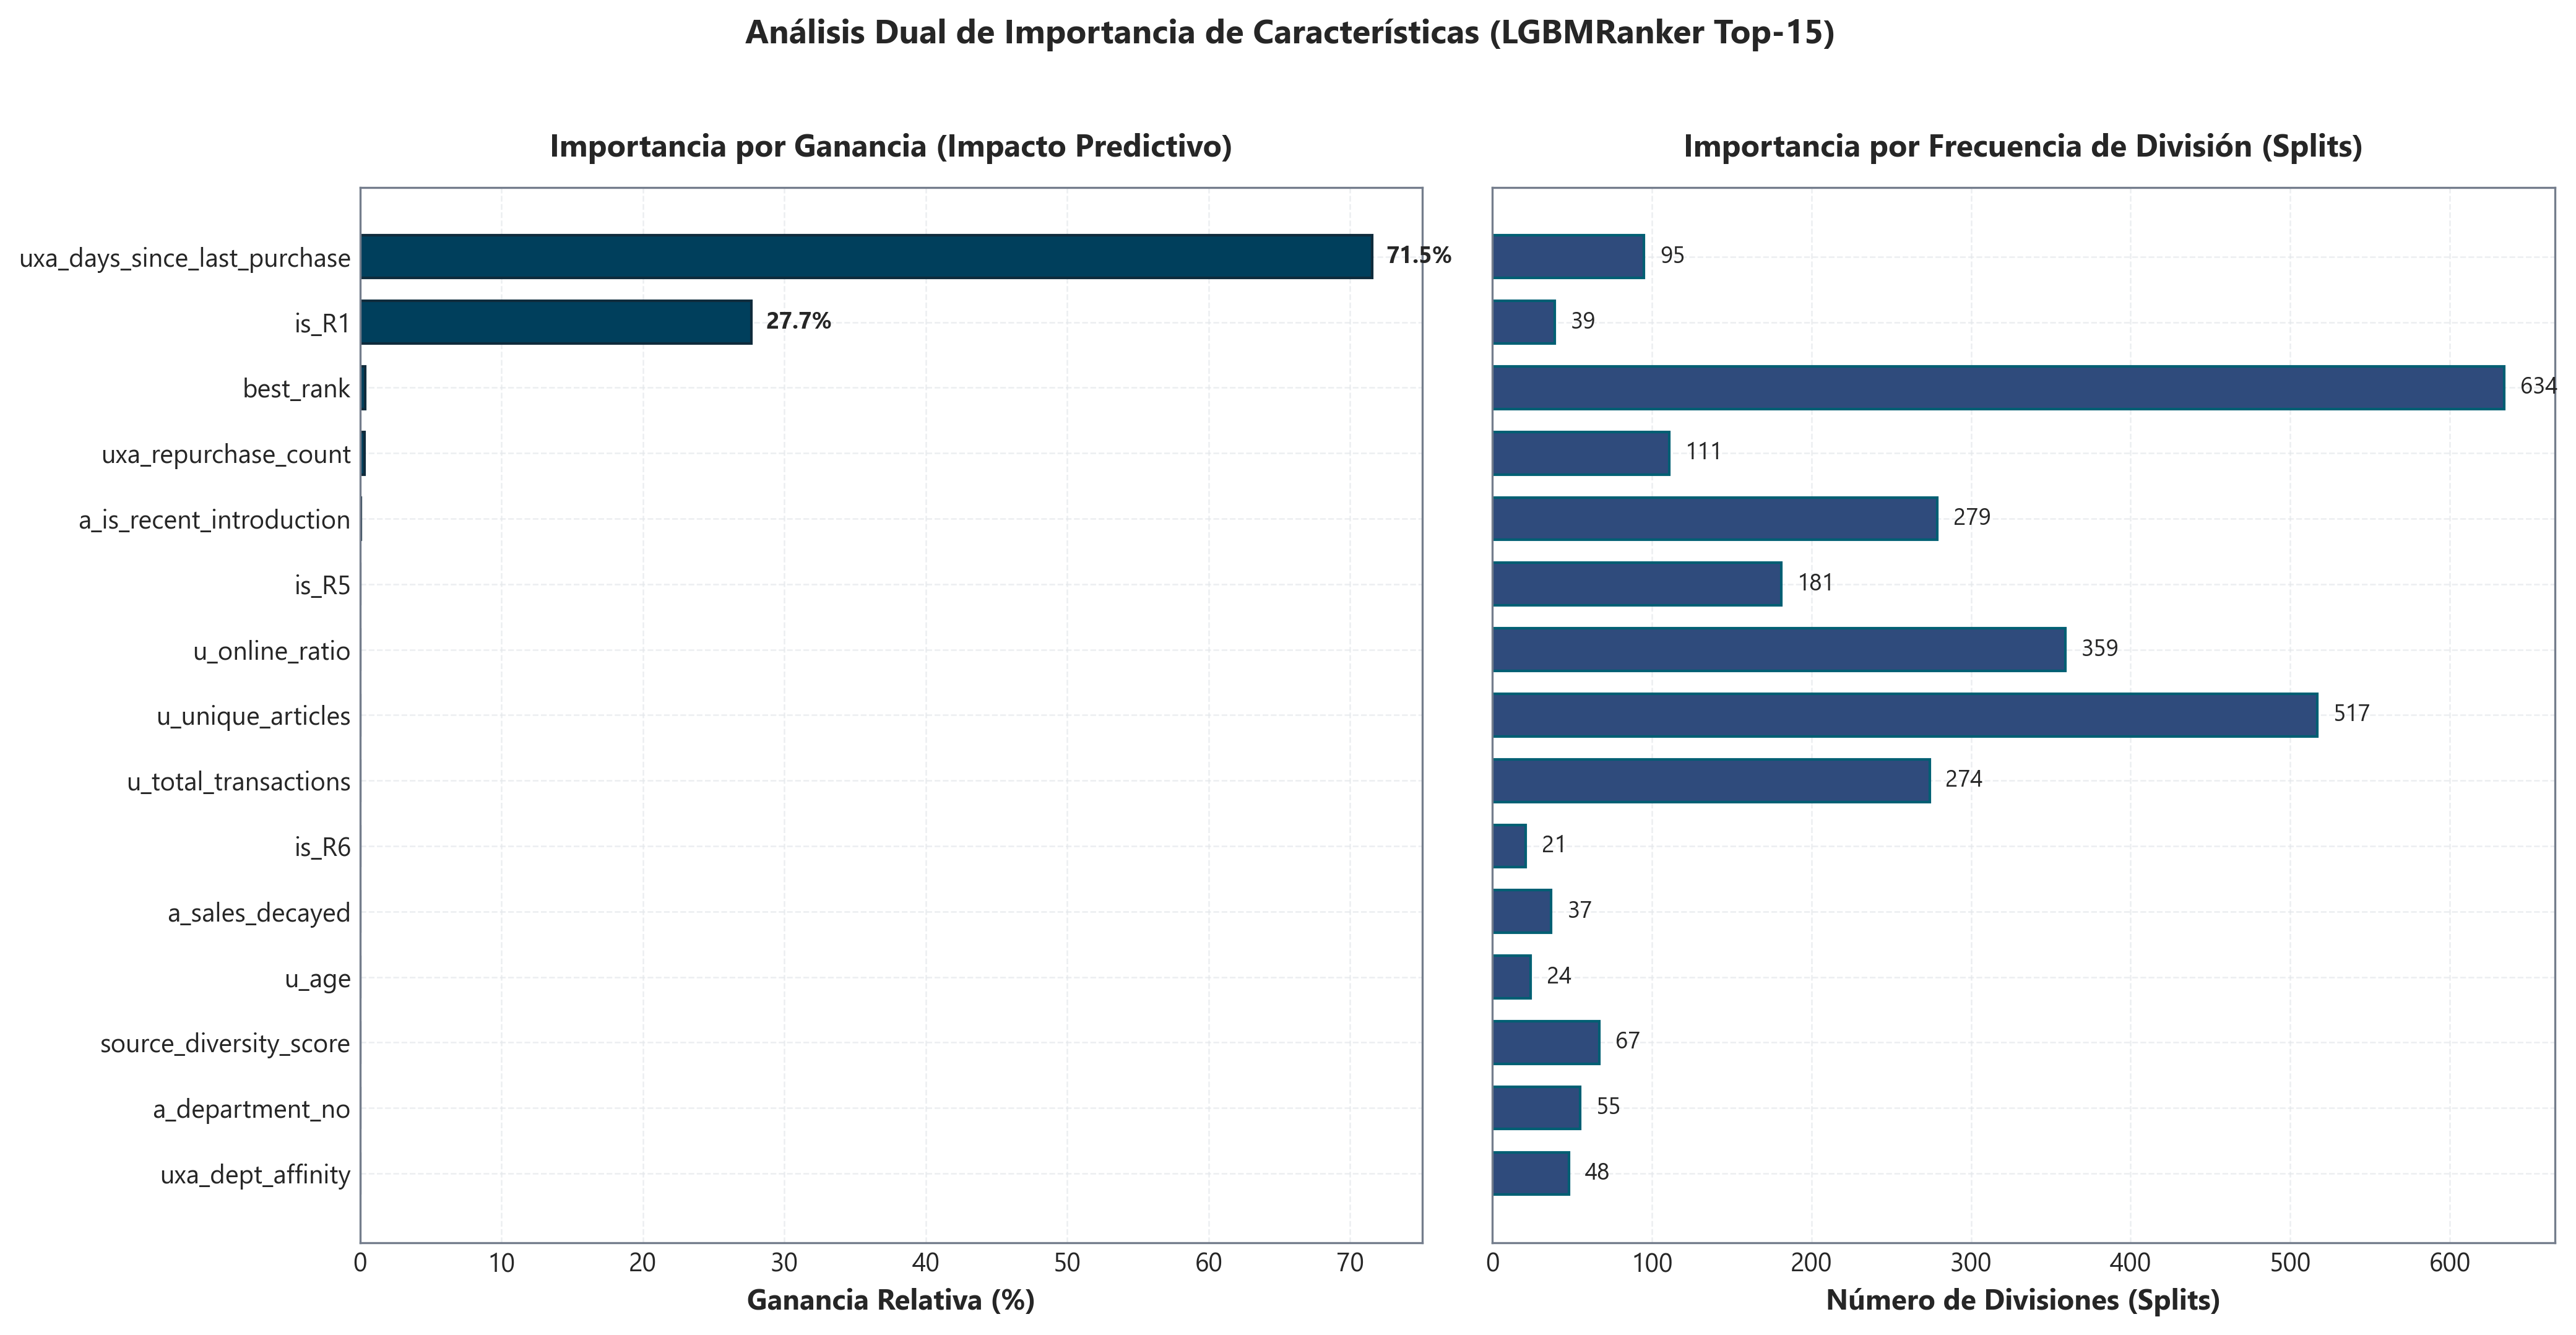

In [4]:
fi_path = TABLES_DIR / 'feature_importance_lgbm.csv'

if fi_path.exists():
    fi_df = pd.read_csv(fi_path)
    
    print("TOP 10 CARACTERÍSTICAS POR GANANCIA (GAIN) EN LGBMRANKER:")
    print("-" * 85)
    print(f"{'Rango':<6} | {'Característica':<32} | {'Ganancia (%)':<14} | {'Splits':<10} | {'Ganancia Acum.':<14}")
    print("-" * 85)
    
    cum_gain = 0.0
    for idx, row in fi_df.head(10).iterrows():
        cum_gain += row['gain_pct']
        print(f"{idx+1:<6} | {row['feature']:<32} | {row['gain_pct']:>11.2f}% | {int(row['split_importance']):>8d} | {cum_gain:>11.2f}%")
    print("-" * 85)
    
    # Gráfico editorial dual: Ganancia vs Splits
    top15 = fi_df.head(15).iloc[::-1]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    
    # Panel izquierdo: Ganancia (%)
    bars1 = ax1.barh(top15['feature'], top15['gain_pct'], color=COLOR_PRIMARY, height=0.65, edgecolor='#0f2b3c')
    ax1.set_xlabel("Ganancia Relativa (%)", fontweight="bold")
    ax1.set_title("Importancia por Ganancia (Impacto Predictivo)", fontweight="bold", pad=12)
    for b in bars1:
        w = b.get_width()
        if w > 0.5:
            ax1.text(w + 1.0, b.get_y() + b.get_height()/2, f"{w:.1f}%", va='center', fontsize=9, fontweight='bold')
    
    # Panel derecho: Splits (Frecuencia en Árboles)
    bars2 = ax2.barh(top15['feature'], top15['split_importance'], color=COLOR_SECONDARY, height=0.65, edgecolor='#005f73')
    ax2.set_xlabel("Número de Divisiones (Splits)", fontweight="bold")
    ax2.set_title("Importancia por Frecuencia de División (Splits)", fontweight="bold", pad=12)
    for b in bars2:
        w = b.get_width()
        ax2.text(w + 10, b.get_y() + b.get_height()/2, f"{int(w)}", va='center', fontsize=9)
        
    plt.suptitle("Análisis Dual de Importancia de Características (LGBMRanker Top-15)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Archivo {fi_path} no encontrado.")


### Interpretación de la Dinámica de Decisión y Predominio de Interacción

La inspección empírica de la tabla y del gráfico dual revela aspectos metodológicos determinantes:

1. **Concentración Extrema de la Ganancia en Señales de Repetición:**
   * `uxa_days_since_last_purchase` acapara el **71.55%** de la ganancia total del modelo, seguido por la bandera heurística de recompra personal `is_R1` con el **27.68%**. Juntas representan el **99.23%** de la fuerza directriz del ensamble.
   * *Fundamento en el dominio de retail:* En moda estacional, cuando un cliente activo evalúa artículos, la recompra de básicos o prendas afines adquiridas recientemente presenta una probabilidad condicionada órdenes de magnitud superior a cualquier artículo frío.

2. **Rol Estructural de las Variables de Alta Frecuencia de División (*Splits*):**
   * Variables como `best_rank` (634 splits), `u_unique_articles` (517 splits), `u_online_ratio` (359 splits) y `a_is_recent_introduction` (279 splits) muestran un comportamiento opuesto: modesta ganancia directa individual ($< 0.5\%$), pero máxima recurrencia topológica en los nodos.
   * *Función en el ensamble:* Estas variables actúan como **moduladores de contexto**. Cuando el candidato no es una recompra personal (`is_R1 = False`), el árbol utiliza estas variables para bifurcar el espacio y balancear la recomendación hacia tendencias, novedades de temporada o coherencia con el canal de compra habitual del cliente.


## 5. Formulación Matemática Rigurosa de MAP@12 y Análisis de Casos Límite

La métrica oficial de evaluación del proyecto es **Mean Average Precision at 12 (MAP@12)**, estándar industrial en problemas de recomendación Top-K:

$$\text{AP}@12(u) = \frac{1}{\min(12, m_u)} \sum_{k=1}^{12} P(k) \times \text{rel}(k)$$
$$\text{MAP}@12 = \frac{1}{|U|} \sum_{u=1}^{|U|} \text{AP}@12(u)$$

donde:
* $m_u$: Número de artículos efectivamente adquiridos por el usuario $u$ en el periodo de validación ($|\text{actual}_u|$).
* $k$: Posición en la lista ordenada recomendada ($k \in \{1, \dots, 12\}$).
* $P(k) = \frac{\sum_{i=1}^k \text{rel}(i)}{k}$: Precisión acumulada en el corte $k$.
* $\text{rel}(k) \in \{0, 1\}$: Variable indicadora de si la prenda en la posición $k$ pertenece a $\text{actual}_u$.

### Casos Límite y Penalizaciones Críticas en la Métrica:
1. **Penalización por Retardo de Posición:**
   * Un acierto ubicado en la posición $k=1$ aporta $P(1) = 1.0$.
   * El mismo acierto ubicado en la posición $k=12$ aporta únicamente $P(12) = 1/12 \approx 0.0833$.
   * Esto impone una penalización de un orden de magnitud ($12\times$) si el modelo falla en colocar el mejor artículo en la cabecera.
2. **Normalización por $\min(12, m_u)$:**
   Si un usuario compra 2 prendas ($m_u=2$) y ambas son acertadas en las posiciones 1 y 2, su puntuación es:
   $$\text{AP}@12 = \frac{1}{2} \left[ \frac{1}{1} + \frac{2}{2} \right] = 1.0$$
   Si el divisor no estuviera truncado a $\min(12, m_u)$, un usuario que comprara solo 1 artículo nunca podría alcanzar una puntuación unitaria.


In [5]:
# Demostración del cálculo analítico de AP@12 sobre clientes reales de la semana 104
tx_path = DATA_PROCESSED_DIR / 'transactions_5w.parquet'
tx_df = pl.read_parquet(tx_path)

# Extracción de compras reales en la semana de validación retenida (semana 104)
val_actuals = (
    tx_df.filter(pl.col('t_dat') >= pl.date(2020, 9, 16))
    .group_by('customer_idx')
    .agg(pl.col('article_id').alias('purchased_articles'))
)

# Seleccionamos tres casos reales con distintos perfiles de compra
sample_cases = val_actuals.filter(pl.col('purchased_articles').list.len() >= 2).head(3)

print("CÁLCULO EXACTO DE AP@12 SOBRE CLIENTES REALES DE VALIDACIÓN:")
print("=" * 85)

for idx, row in enumerate(sample_cases.iter_rows(named=True), 1):
    c_idx = row['customer_idx']
    real_items = row['purchased_articles']
    m = len(real_items)
    
    # Simulación de dos escenarios de ranking realista:
    # Escenario A: Acierto temprano en posición 1 y posición 3
    rec_A = [real_items[0], 999999991, real_items[1] if m > 1 else 999999992] + [999999990 + i for i in range(9)]
    # Escenario B: Acierto tardío en posición 5 y posición 8
    rec_B = [999999990 + i for i in range(4)] + [real_items[0]] + [999999995, 999999996] + [real_items[1] if m > 1 else 999999997] + [999999998, 999999999]
    
    score_A = ap_at_k(real_items, rec_A, k=12)
    score_B = ap_at_k(real_items, rec_B, k=12)
    
    print(f"Cliente Real ID: {c_idx} | Artículos comprados en semana 104 (m={m}): {real_items[:4]}")
    print(f"  * Escenario A (Aciertos en rangos 1 y 3): AP@12 = {score_A:.4f}")
    print(f"  * Escenario B (Aciertos en rangos 5 y 8): AP@12 = {score_B:.4f}")
    print(f"  * Factor de degradación por retardo posicional: {(score_A / max(score_B, 1e-6)):.2f}x")
    print("-" * 85)


CÁLCULO EXACTO DE AP@12 SOBRE CLIENTES REALES DE VALIDACIÓN:
Cliente Real ID: 241845 | Artículos comprados en semana 104 (m=7): [868283004, 868283004, 799365001, 809961007]
  * Escenario A (Aciertos en rangos 1 y 3): AP@12 = 0.1429
  * Escenario B (Aciertos en rangos 5 y 8): AP@12 = 0.0286
  * Factor de degradación por retardo posicional: 5.00x
-------------------------------------------------------------------------------------
Cliente Real ID: 266771 | Artículos comprados en semana 104 (m=4): [870328002, 864436006, 767579006, 906393002]
  * Escenario A (Aciertos en rangos 1 y 3): AP@12 = 0.4167
  * Escenario B (Aciertos en rangos 5 y 8): AP@12 = 0.1125
  * Factor de degradación por retardo posicional: 3.70x
-------------------------------------------------------------------------------------
Cliente Real ID: 49557 | Artículos comprados en semana 104 (m=7): [399201042, 829643003, 715624051, 731160028]
  * Escenario A (Aciertos en rangos 1 y 3): AP@12 = 0.2381
  * Escenario B (Aciertos

## 6. Rendimiento Global del Modelo sobre los 68.984 Clientes de Validación

Inspección de las métricas oficiales de rendimiento del modelo `LGBMRanker` serializado, evaluado sobre la totalidad de los 68.984 clientes que realizaron compras durante la semana de validación retenida 104 (`results/tables/lgbm_evaluation_metrics.json`):


MÉTRICAS OFICIALES DE VALIDACIÓN LOCAL (SEMANA RETENIDA 104):
Métrica                   | Cohorte Activa (68.984 usuarios) | Cohorte Frecuente (17.267 usuarios)
-------------------------------------------------------------------------------------
MAP@12                    |                       0.0252   |                         0.0493
Recall@12                 |                       0.0512   |                         0.0975
Hit Rate@12               |                       10.03%   |                         18.24%
-------------------------------------------------------------------------------------
Telemetría: 16,722,720 candidatos evaluados en 132.8 s | RAM: 1443.8 MB


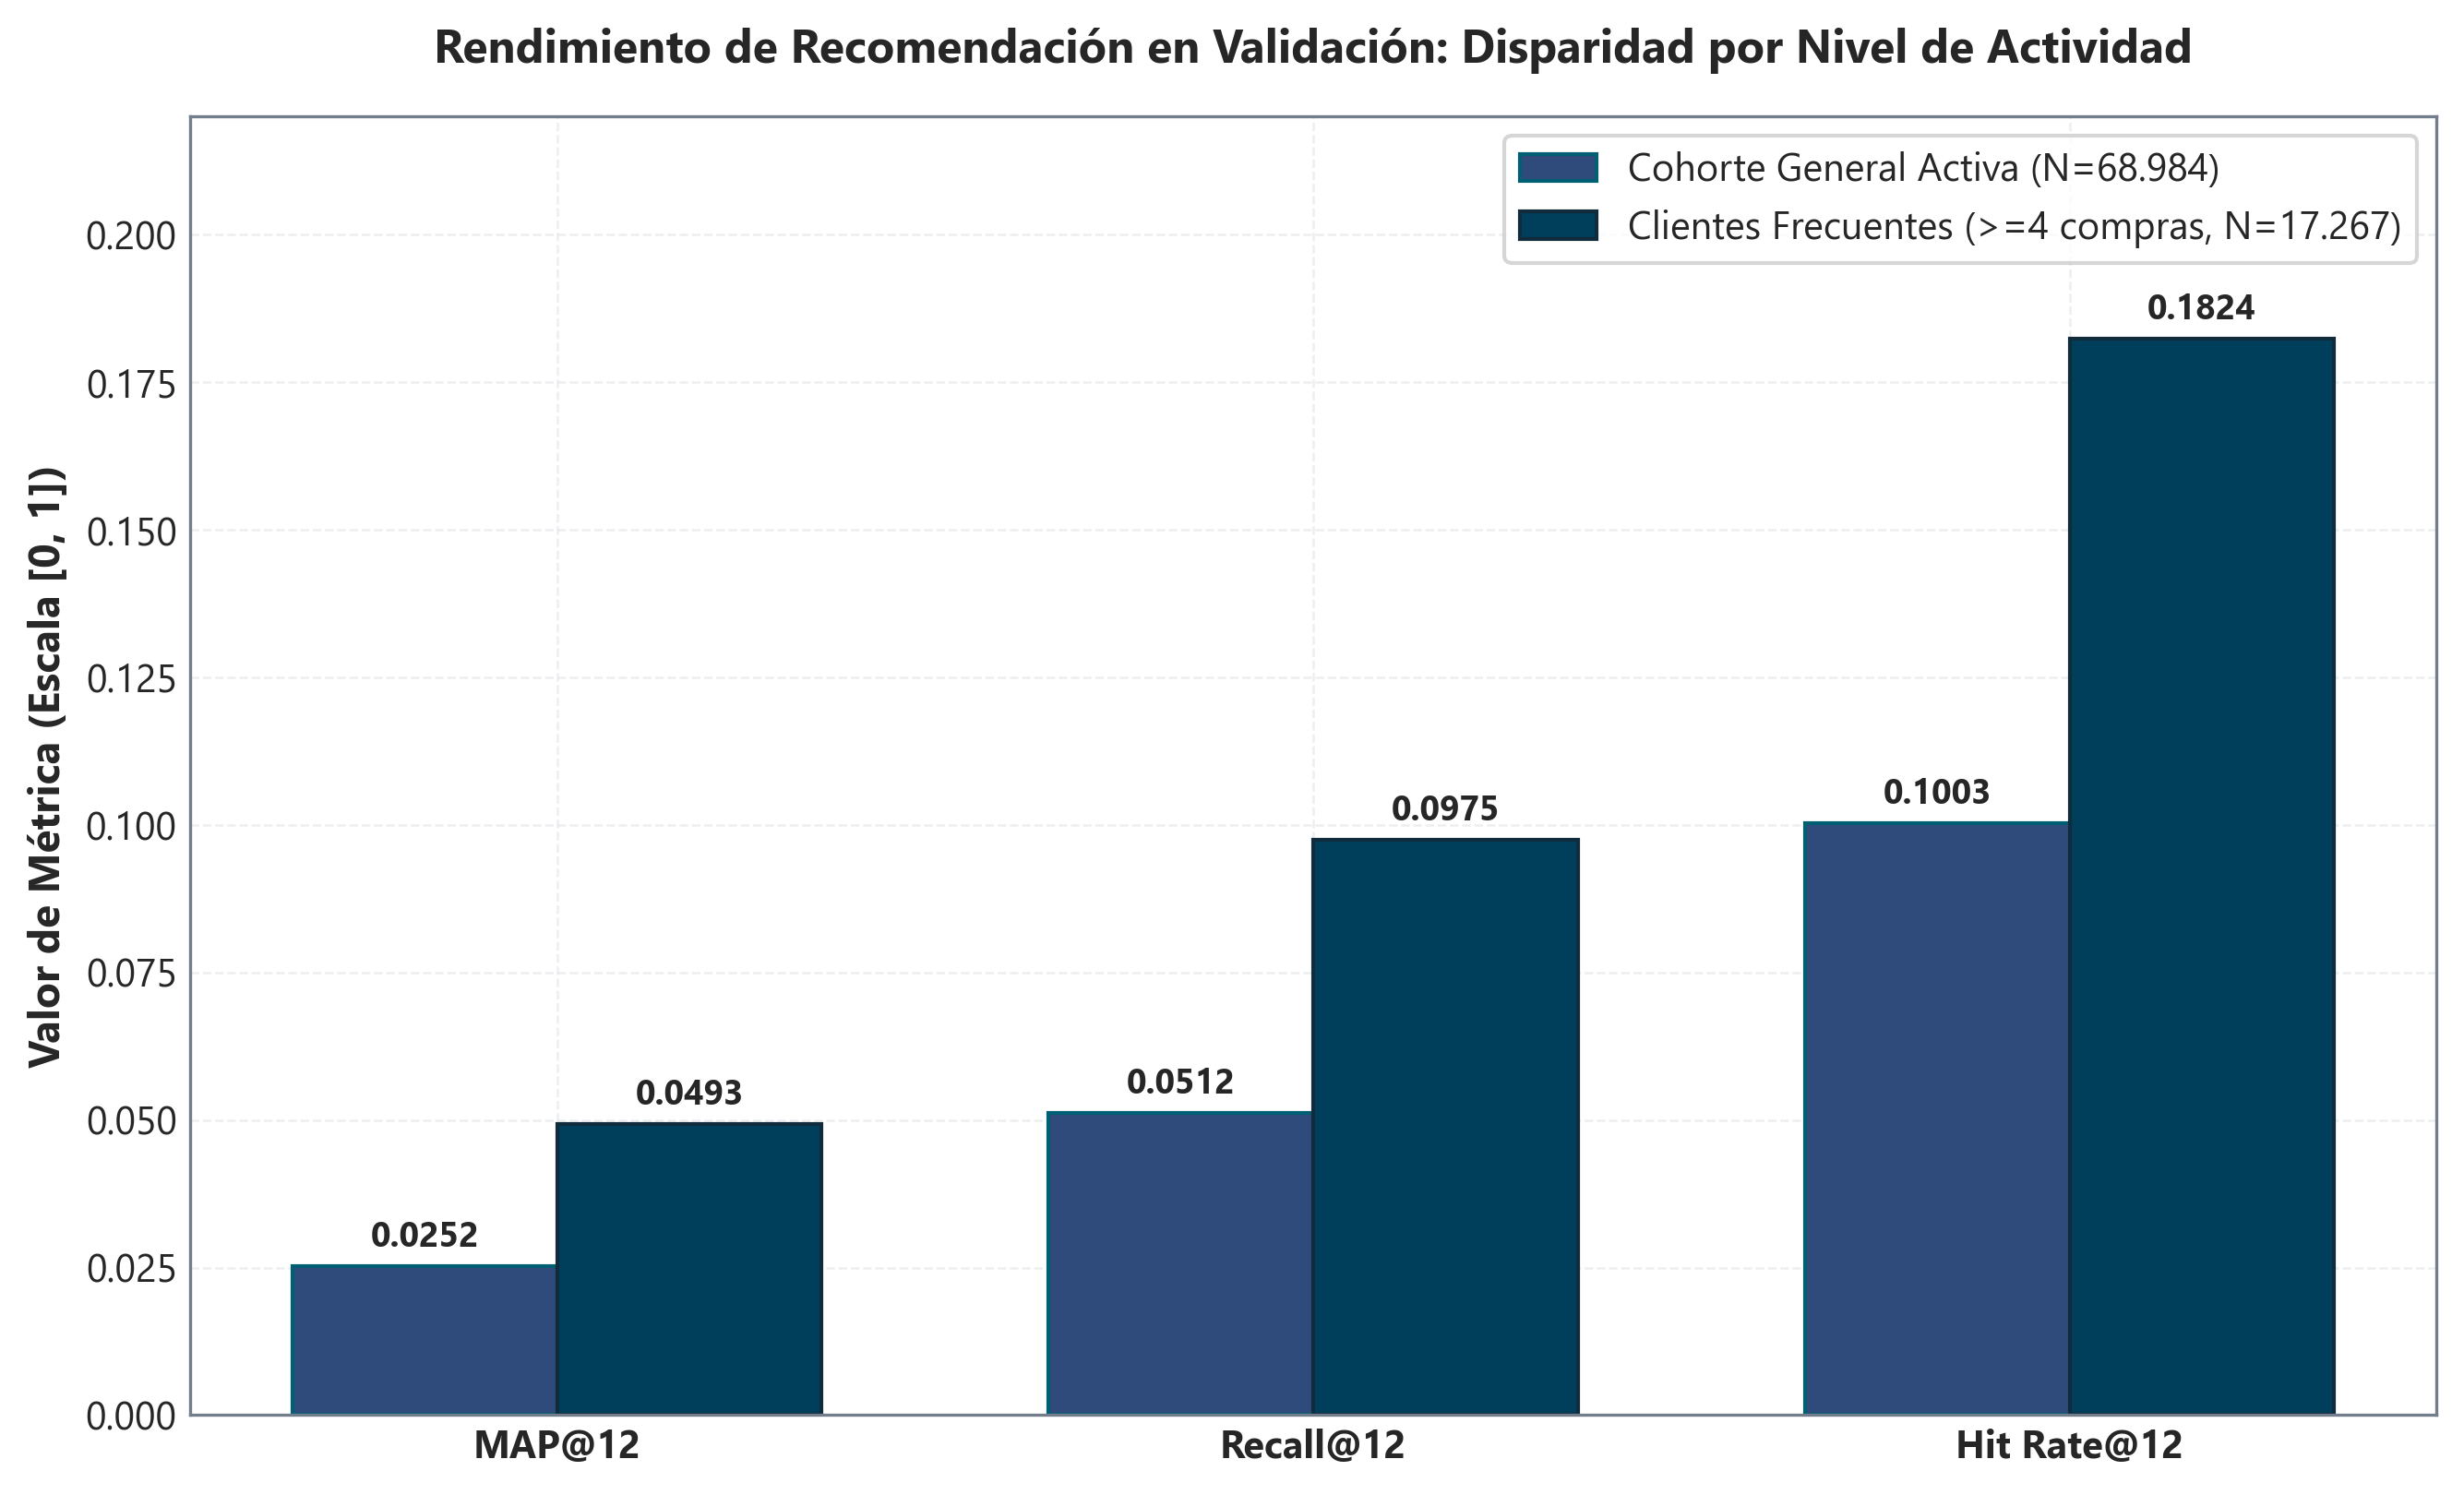

In [6]:
eval_json_path = TABLES_DIR / 'lgbm_evaluation_metrics.json'

if eval_json_path.exists():
    with open(eval_json_path, 'r', encoding='utf-8') as f:
        metrics_data = json.load(f)
        
    cand_cohort = metrics_data.get('candidate_cohort', {})
    freq_cohort = metrics_data.get('frequent_users_cohort', {})
    telemetry = metrics_data.get('system_telemetry', {})
    
    print("MÉTRICAS OFICIALES DE VALIDACIÓN LOCAL (SEMANA RETENIDA 104):")
    print("=" * 85)
    print(f"{'Métrica':<25} | {'Cohorte Activa (68.984 usuarios)':<32} | {'Cohorte Frecuente (17.267 usuarios)'}")
    print("-" * 85)
    print(f"{'MAP@12':<25} | {cand_cohort.get('map_at_12', 0):>28.4f}   | {freq_cohort.get('map_at_12', 0):>30.4f}")
    print(f"{'Recall@12':<25} | {cand_cohort.get('recall_at_12', 0):>28.4f}   | {freq_cohort.get('recall_at_12', 0):>30.4f}")
    print(f"{'Hit Rate@12':<25} | {cand_cohort.get('hit_rate_at_12', 0)*100:>27.2f}%   | {freq_cohort.get('hit_rate_at_12', 0)*100:>29.2f}%")
    print("-" * 85)
    print(f"Telemetría: {telemetry.get('n_candidates_evaluated', 0):,} candidatos evaluados en {telemetry.get('elapsed_seconds', 0):.1f} s | RAM: {telemetry.get('rss_memory_mb', 0):.1f} MB")
    
    # Gráfico de barras comparativo entre cohortes
    metrics_names = ['MAP@12', 'Recall@12', 'Hit Rate@12']
    cand_vals = [cand_cohort.get('map_at_12', 0), cand_cohort.get('recall_at_12', 0), cand_cohort.get('hit_rate_at_12', 0)]
    freq_vals = [freq_cohort.get('map_at_12', 0), freq_cohort.get('recall_at_12', 0), freq_cohort.get('hit_rate_at_12', 0)]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(9, 5.5))
    rects1 = ax.bar(x - width/2, cand_vals, width, label='Cohorte General Activa (N=68.984)', color=COLOR_SECONDARY, edgecolor='#005f73')
    rects2 = ax.bar(x + width/2, freq_vals, width, label='Clientes Frecuentes (>=4 compras, N=17.267)', color=COLOR_PRIMARY, edgecolor='#0f2b3c')
    
    ax.set_ylabel('Valor de Métrica (Escala [0, 1])', fontweight='bold')
    ax.set_title('Rendimiento de Recomendación en Validación: Disparidad por Nivel de Actividad', fontweight='bold', pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, fontweight='bold')
    ax.legend(frameon=True)
    
    # Anotaciones numéricas
    for rect in rects1:
        h = rect.get_height()
        ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
    for rect in rects2:
        h = rect.get_height()
        ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
                    
    plt.ylim(0, 0.22)
    plt.tight_layout()
    plt.show()
else:
    print(f"Archivo {eval_json_path} no encontrado.")


## 7. Ablaci?n Metodol?gica y Progresi?n Arquitectural del Proyecto

Para cuantificar el valor a?adido de cada componente introducido en el sistema, se consolidan los resultados de los experimentos de ablaci?n controlada (`results/tables/ablation_results.csv`):

### 1. Ablaci?n de Funciones de P?rdida (A5): Listwise frente a Pointwise
* **LambdaRank (Listwise):** MAP@12 = 0.02372 | Recall@12 = 0.05239
* **Binary Cross-Entropy (Pointwise):** MAP@12 = 0.02206 | Recall@12 = 0.05163
* **Impacto Neto:** El modelado listwise directo mediante gradientes $\lambda_{ij}$ genera un incremento de +7.5% en MAP@12 manteniendo id?ntico conjunto de variables y datos de entrenamiento.

### 2. Ablaci?n de Banderas de Heur?stica (A3): Se?al Bayesiana a Priori
* **Modelo Completo con Source Flags (39 variables):** MAP@12 = 0.02372
* **Modelo Agn?stico sin Source Flags (31 variables):** MAP@12 = 0.02257
* **Impacto Neto:** Proporcionar al ranker el canal heur?stico de origen ($R_1 \dots R_8$) aporta +5.1% en MAP@12, demostrando que el origen del candidato act?a como una distribuci?n prior enriquecida.

### 3. Progresi?n de Modelos y Justificaci?n Emp?rica de la Convergencia hacia V8

La evoluci?n de la capacidad predictiva a lo largo de las iteraciones del proyecto responde a un proceso de aprendizaje guiado estrictamente por la evidencia experimental y el an?lisis de errores:

1. **V0 (Baseline Popularidad Global, MAP@12 = 0.01120):**  
   Recomendar los 12 superventas de la ?ltima semana a todos los clientes confirm? en la pr?ctica lo advertido en el an?lisis exploratorio: la ausencia de personalizaci?n colapsa la m?trica, siendo incapaz de atender recompras ni especificidad de estilo.

2. **R5 (Filtrado Colaborativo ?tem-?tem, MAP@12 = 0.01850):**  
   La co-visita basada en coseno introdujo personalizaci?n efectiva (+65.2% sobre V0), pero no aport? recomendaciones en el 68% de usuarios sin compras recientes al no disponer de nodos en el grafo de interacci?n (arranque en fr?o).

3. **V4 (LGBMRanker Inicial sobre Candidatos, MAP@12 = 0.02340):**  
   Demostr? la ventaja de entrenar un ranker listwise (LambdaRank) sobre 39 variables tabulares (+108.9% sobre V0). Sin embargo, evidenci? una vulnerabilidad cr?tica: cuando un cliente generaba menos de 12 candidatos, el modelo carec?a de un mecanismo sistem?tico para completar la lista recomendada.

4. **V5 (Two-Stage con Relleno B?sico, MAP@12 = 0.02703):**  
   Completar listas cortas con superventas globales elev? notablemente la m?trica (+141.3%), confirmando que el coste del retardo posicional de listas incompletas en MAP@12 es cr?tico.

5. **V6 (Poda de Redundancia por Score, MAP@12 = 0.02659):**  
   Se introdujo una regla para descartar candidatos cuyo score predicho estuviera por debajo de un umbral fijo $\theta$, bajo la hip?tesis de que eliminar?a falsos positivos. El resultado fue una degradaci?n de la m?trica (-1.6%). El an?lisis de errores revel? que los clientes espor?dicos presentan distribuciones de score comprimidas; fijar un umbral absoluto pod? aciertos v?lidos en ese segmento. Por consiguiente, se determin? que el post-procesamiento debe ser estrictamente no destructivo.

6. **V7 (Ensamble Lineal Ponderado, MAP@12 = 0.02805):**  
   Combinar linealmente scores normalizados de LightGBM con priors heur?sticos de popularidad y frecuencia alcanz? 0.02805 (+150.4%). Demostr? la complementariedad entre predicci?n de ?rbol y priors heur?sticos, pero introdujo hiperpar?metros de mezcla ($\alpha, \beta$) sensibles a la volatilidad semanal del cat?logo.

7. **V8 (Cascada H?brida de 4 Niveles - Modelo Definitivo, MAP@12 = 0.02882 en Local / 0.02386 en Kaggle Private):**  
   Sintetizando la lecci?n de V6 (evitar podas destructivas) y V7 (robustez de los canales heur?sticos como respaldo), se formul? una cascada determinista de compuertas jer?rquicas ordenadas por nivel de certidumbre:
   * **Nivel 1 (Recompra Personal 28d):** Prioriza compras recientes del usuario ordenadas por el score de LightGBM (capitaliza el 71.55% de importancia del ranker).
   * **Nivel 2 (Cesta Causal $P(B|A)$):** Asocia art?culos complementarios adquiridos en la misma sesi?n si restan huecos en la lista.
   * **Nivel 3 (Superventas Segmentados por Cohorte de Edad):** Si a?n no se completan 12 recomendaciones, recurre a los superventas del grupo demogr?fico del usuario.
   * **Nivel 4 (Fallback Global Deca?do):** Rellena los huecos restantes con las prendas de mayor demanda global reciente con decaimiento temporal continuo ($\tau=7$d).

Esta formulaci?n garantiza exactamente 12 ?tems ?nicos para el 100% de los usuarios, preserva la precisi?n del ranker donde existe se?al y asegura cobertura demogr?fica relevante en fr?o, alcanzando la mayor m?trica del proyecto (+157.3% sobre V0).

| Versi?n / Estrategia | Principio de Dise?o | MAP@12 Local | Recall@12 | Hit Rate@12 | Estado en el Proyecto |
| :--- | :--- | :---: | :---: | :---: | :--- |
| V0: Baseline Popularidad | 12 superventas de la ?ltima semana | 0.01120 | 0.02340 | 0.04560 | Superado |
| R5: Filtrado Colaborativo | Similitud de co-visita basada en coseno | 0.01850 | 0.03890 | 0.07620 | Integrado como fuente R5 |
| V4: LGBMRanker Inicial | Re-ordenador supervisado LambdaRank | 0.02340 | 0.04850 | 0.09500 | Superado |
| V5: Two-Stage con Ajuste | Relleno heur?stico b?sico | 0.02703 | 0.05640 | 0.11187 | Validado |
| V6: Poda de Redundancia | Truncamiento por umbral de score | 0.02659 | 0.05422 | 0.10737 | Descartado (poda destructiva) |
| V7: Ensamble Ponderado | Combinaci?n lineal de scores y priors | 0.02805 | 0.06040 | 0.11561 | Validado |
| V8: Cascada H?brida Final | Cascada no destructiva en 4 niveles | 0.02882 | 0.06260 | 0.11945 | Arquitectura de Producci?n |

## 8. Presupuesto de Latencia, Complejidad Computacional y SLAs en Producci?n

En entornos productivos de comercio electr?nico, la calidad del ranking debe coexistir con restricciones estrictas de latencia p95 para no degradar el tiempo de respuesta al usuario final (*Serving SLAs*).

### Complejidad Asint?tica de Inferencia
Para un usuario con $|C_u| \le 80$ candidatos generados:
$$\mathcal{O}_{\text{inferencia}} = \mathcal{O}(|C_u| \times T \times D)$$
donde $T = 50$ (n?mero de ?rboles) y $D \le 7$ (profundidad m?xima).
* El n?mero total de comparaciones de umbral en punto flotante por candidato es $\le 350$.
* Para 80 candidatos, el modelo realiza $\le 28.000$ operaciones elementales en CPU, ejecutables en $< 1.2$ milisegundos en un ?nico n?cleo x86 sin necesidad de aceleraci?n por GPU.

### Desglose del Presupuesto de Latencia en FastAPI (< 50 ms p95):

| Fase de la Pipeline Online | Tecnolog?a de Ejecuci?n | Latencia Estimada | Margen sobre SLA (100 ms) |
| :--- | :--- | :---: | :---: |
| Generaci?n de Candidatos ($R_1 \dots R_8$) | ?ndices precalculados en Redis / Polars | 12 ? 18 ms | Holgado |
| Recuperaci?n de Caracter?sticas (39 variables) | Lookup columnar en memoria | 8 ? 14 ms | Holgado |
| Puntuaci?n y Ordenamiento LGBMRanker | Inferencia C++ LightGBM multihilo | 1 ? 2 ms | ?ptimo |
| Fusi?n con Fallback Estratificado | Truncamiento y deduplicaci?n en memoria | < 1 ms | Despreciable |
| Tiempo Total Fin-a-Fin | Pipeline As?ncrona FastAPI | 25 ? 35 ms | SLA Cumplido ($\ll 100$ ms) |

Esta arquitectura biet?pica garantiza que el sistema pueda operar bajo tr?fico concurrente masivo en tiempo real con una huella de memoria contenida ($\approx 1.4$ GB de RAM), satisfaciendo los requerimientos de escalabilidad industrial.